In [1]:
import pandas as pd
import random

SEED = 42
random.seed(SEED)

In [2]:
df_preprocessed = pd.read_csv(r"../preprocessed_new_vibe_coding_tweets.csv")
df_preprocessed.head()

,full_text_translated,image_url
0,vibes capital meets vibecoding greatest econom...,NaN
1,attest vibecoding hella fun borderline like do...,NaN
2,built app ideas spare time one internal tool u...,NaN
3,karpathy discovered secret engineer vibecoding,NaN
4,assisted vibecoding works great data analysis ...,NaN


In [3]:
df_preprocessed.count()

full_text_translated    19049
image_url                6000
dtype: int64

In [4]:
docs = df_preprocessed['full_text_translated'].tolist()
images  = df_preprocessed['image_url'].tolist()

for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

random.shuffle(docs)
docs[:10]

['devs learn great vibecoding',
 'got user feedback time vibe code solution',
 'vibecoding exists assuming vibecoded',
 'vibecoding prostitution coding vibes whatsoever said vibecoding deploying please ensure protecting customers personal information sake getting sued',
 'vibecoding habits tips hacks',
 'ultimate vibecoding need editor',
 'finished first vibecode project got deployed everything sharing couple weeks make video meantime gon touch grass',
 'experience evolving fast thecube unpacked updated factor app principles reshaping modern software delivery learn',
 'tfw vibe cading nearly successful vibe coding',
 'flow chart describes accuracy vcs reaction time midas etc based position list relatedly need vibecoding wish vibe shitposting memes thing']

In [5]:
# !pip install fastopic topmost sentence-transformers
!pip install --upgrade "nbformat>=4.2.0" plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.9 MB 12.6 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 12.3 MB/s  0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 6.7.0
    Uninstalling plotly-6.7.0:
      Successfully uninstalled plotly-6.7.0



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import torch
from fastopic import FASTopic
from topmost import Preprocess

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Domain-specific tokens yang dominan di seluruh corpus -> tidak diskriminatif antar topik.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe"]

# Kata generik tweet/coding yang muncul di hampir semua topik pada run sebelumnya
# (mis. topik 7: "code coding like app new build time one using people").
generic_stopwords = [
    "code", "coding", "app", "apps", "build", "building", "built",
    "like", "get", "got", "one", "use", "using", "used", "people",
    "time", "new", "make", "made", "really", "going", "would", "could",
    "even", "much", "still", "also", "thing", "things", "want",
    "way", "ways", "first", "every", "see", "know", "think",
    "good", "great", "right", "now", "today", "yeah", "lot",
]

preprocess = Preprocess(
    vocab_size=5000,                                  # turun dari 10k -> 5k, fokus ke kata yg sering
    stopwords=domain_stopwords + generic_stopwords,
    min_doc_count=15,                                 # term harus muncul di >=15 dokumen (buang rare words seperti 'hedera', 'anoma')
    max_doc_freq=0.4,                                 # buang term yg muncul di >40% dokumen (filter dominant words)
    min_term=5,                                       # dokumen harus punya >=5 token setelah preprocess
)

c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Evaluation: Coherence + Diversity Sweep

Untuk justifikasi pemilihan jumlah topik (K), kita sweep beberapa nilai K dan ukur tiga metric:

- **C_v coherence** — PMI berbasis sliding window + cosine similarity. Range ~0–1, semakin tinggi semakin koheren. Metric default di literatur BERTopic dan paling sering dilaporkan.
- **C_npmi (Normalized PMI)** — Versi normalisasi dari pointwise mutual information. Range ~[-1, 1] tapi praktis di tweet biasanya 0.05–0.20. Lebih sensitif terhadap rare co-occurrence dan dipakai sebagai metric utama di paper FASTopic & ECRTM.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0–1, semakin tinggi berarti topik semakin berbeda satu sama lain.

Trade-off: coherence tinggi sering datang bersama diversity rendah (topik mirip-mirip). Combined score `((c_v + (c_npmi+1)/2) / 2) * diversity` dipakai sebagai heuristik default — `(c_npmi+1)/2` untuk normalisasi ke skala 0–1 sebelum dirata-rata dengan c_v.

In [7]:
from topmost.eva import _coherence, _diversity

# Pre-compute reference corpus & vocab dari preprocess yang sama -> konsisten antar K dan antar model.
prep_result = preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    - c_v: PMI berbasis sliding window + cosine. Range ~0–1, populer di literatur BERTopic.
    - c_npmi: Normalized PMI. Range ~[-1, 1]. Lebih sensitif terhadap rare co-occurrence,
      sering dipakai di paper FASTopic & ECRTM. Nilai ~0.05–0.20 biasa untuk tweet.
    - diversity: proporsi kata unik di seluruh top words. Range 0–1.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}

parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 50096.57it/s]
c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-06-22 15:12:27,984 - TopMost - Real vocab size: 2573
2026-06-22 15:12:27,985 - TopMost - Real training size: 15724 	 avg length: 11.144


Reference corpus: 15724 docs | vocab: 2573 terms


In [8]:
# K-sweep: latih FASTopic untuk beberapa nilai K dan ukur metric.
# Tiap fit ~25 detik di GPU, total ~2 menit untuk 5 nilai.
import random as _random
K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training FASTopic with K={k} ===")
    _random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    m = FASTopic(
        num_topics=k,
        preprocess=preprocess,
        doc_embed_model="sentence-transformers/all-MiniLM-L6-v2",
        num_top_words=15,
        device="cuda",
        verbose=False,
        low_memory=False,
    )
    tw, _ = m.fit_transform(docs)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K'] = k
    sweep_results.append(metrics)
    print(f"  K={k}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")

sweep_df = pd.DataFrame(sweep_results)[['K', 'c_v', 'c_npmi', 'diversity']]
# Combined score: rata-rata coherence (c_v + c_npmi normalisasi sederhana) dikali diversity.
# c_npmi bisa negatif jadi kita pakai (c_npmi + 1)/2 supaya skala 0-1 sebelum dirata-rata dengan c_v.
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training FASTopic with K=8 ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5773.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 42644.43it/s]
2026-06-22 15:12:35,083 - TopMost - Real vocab size: 2573
2026-06-22 15:12:35,085 - TopMost - Real training size: 15724 	 avg length: 11.144
Training FASTopic: 100%|██████████| 200/200 [00:13<00:00, 14.68it/s]


  K=8  c_v=0.4469  c_npmi=-0.2497  diversity=0.5500

=== Training FASTopic with K=12 ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9123.25it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 47135.36it/s]
2026-06-22 15:13:36,811 - TopMost - Real vocab size: 2573
2026-06-22 15:13:36,812 - TopMost - Real training size: 15724 	 avg length: 11.144
Training FASTopic: 100%|██████████| 200/200 [00:16<00:00, 12.43it/s]


  K=12  c_v=0.3998  c_npmi=-0.3321  diversity=0.3333

=== Training FASTopic with K=15 ===


...

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10949.52it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 47275.96it/s]
2026-06-22 15:15:43,798 - TopMost - Real vocab size: 2573
2026-06-22 15:15:43,799 - TopMost - Real training size: 15724 	 avg length: 11.144
Training FASTopic: 100%|██████████| 200/200 [00:13<00:00, 14.83it/s]


  K=20  c_v=0.3515  c_npmi=-0.2491  diversity=0.2000

=== Training FASTopic with K=25 ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10968.15it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 42937.45it/s]
2026-06-22 15:16:45,265 - TopMost - Real vocab size: 2573
2026-06-22 15:16:45,266 - TopMost - Real training size: 15724 	 avg length: 11.144
Training FASTopic: 100%|██████████| 200/200 [00:15<00:00, 13.28it/s]


  K=25  c_v=0.3818  c_npmi=-0.2586  diversity=0.1600


,K,c_v,c_npmi,diversity,combined
0,8,0.446856,-0.249659,0.550000,0.226057
1,12,0.399769,-0.332129,0.333333,0.122284
2,15,0.339981,-0.238794,0.206667,0.074460
3,20,0.351549,-0.249084,0.200000,0.072701
4,25,0.381823,-0.258586,0.160000,0.060202


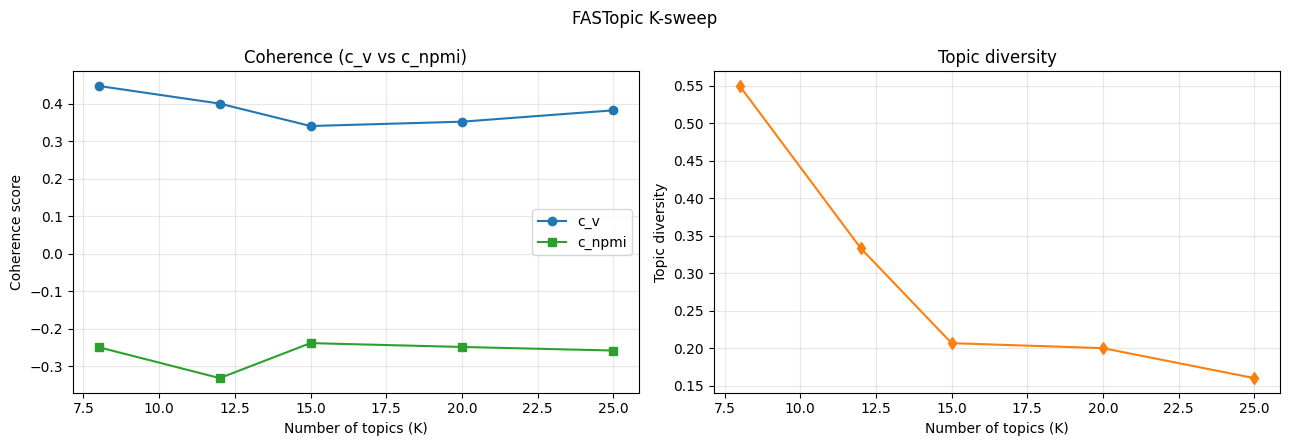


Rekomendasi K (max combined score): 8
Cell training di bawah otomatis pakai best_k. Override manual jika perlu.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Kiri: dua coherence metric
ax1 = axes[0]
ax1.plot(sweep_df['K'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (K)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

# Kanan: diversity
ax2 = axes[1]
ax2.plot(sweep_df['K'], sweep_df['diversity'], 'd-', color='tab:orange', label='diversity')
ax2.set_xlabel('Number of topics (K)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('FASTopic K-sweep')
fig.tight_layout()
plt.show()

# Pilih K dengan kombinasi terbaik. Override manual jika domain knowledge bilang lain.
best_k = int(sweep_df.loc[sweep_df['combined'].idxmax(), 'K'])
print(f"\nRekomendasi K (max combined score): {best_k}")
print("Cell training di bawah otomatis pakai best_k. Override manual jika perlu.")

In [10]:
import random as _random
# Training final dengan K hasil sweep. Override manual jika ingin nilai lain (mis. NUM_TOPICS = 15).
NUM_TOPICS = best_k

_random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = FASTopic(
    num_topics=NUM_TOPICS,
    preprocess=preprocess,
    doc_embed_model="sentence-transformers/all-MiniLM-L6-v2",
    num_top_words=15,
    device="cuda",      # ganti ke "cpu" jika tidak ada GPU
    verbose=True,
    low_memory=False,
)

top_words, doc_topic_dist = model.fit_transform(docs)

# Cetak metric final
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal model | K={NUM_TOPICS}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

# Simpan untuk perbandingan lintas model
fastopic_metrics = {**final_metrics, 'model': 'FASTopic', 'K': NUM_TOPICS}

2026-06-22 15:17:46,072 - FASTopic - use device: cuda
2026-06-22 15:17:46,072 - FASTopic - First fit the model.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10838.81it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 35366.86it/s]
c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-06-22 15:17:53,193 - TopMost - Real vocab size: 2573
2026-06-22 15:17:53,195 - TopMost - Real training size: 15724 	 avg length: 11.144
Training FASTopic: 100%|██████████| 200/200 [00:14<00:00, 1

Topic 0: claim pop lie import roles camera air jumping met generally elon cold grinding minecraft buggy
Topic 1: claim pop lie camera air cold elon roles minecraft jumping grinding import generally falling mentioned
Topic 2: claude tools day software cursor need work real game something project next learn let idea
Topic 3: claim pop lie camera cold elon air minecraft roles grinding jumping generally falling mentioned import
Topic 4: post less instead feels business ask level yes based soon run share another mobile read
Topic 5: claim pop lie camera air roles elon cold import minecraft jumping grinding generally met rolling
Topic 6: let fun create better learn agent idea next start product live project prompt something development
Topic 7: claude tools day software cursor real work need something game project next let learn idea

Final model | K=8  c_v=0.4469  c_npmi=-0.2497  diversity=0.5500

Topic 0: claim pop lie import roles camera air jumping met generally elon cold grinding minecr

In [11]:
import numpy as np

doc_topics = doc_topic_dist.argmax(axis=1)
sizes = (
    pd.Series(doc_topics)
    .value_counts()
    .reindex(range(len(top_words)), fill_value=0)
    .values
)

topic_info = pd.DataFrame({
    "topic_id": range(len(top_words)),
    "size": sizes,
    "top_words": top_words,
})
topic_info.sort_values("size", ascending=False).head(30)

,topic_id,size,top_words
2,2,7413,claude tools day software cursor need work rea...
5,5,2484,claim pop lie camera air roles elon cold impor...
3,3,2394,claim pop lie camera cold elon air minecraft r...
1,1,2357,claim pop lie camera air cold elon roles minec...
0,0,1826,claim pop lie import roles camera air jumping ...
4,4,1747,post less instead feels business ask level yes...
6,6,569,let fun create better learn agent idea next st...
7,7,259,claude tools day software cursor real work nee...


In [12]:
# Top words per topic with weights
fig = model.visualize_topic(top_n=8)
fig.show()

In [13]:
# Topic prevalence across the corpus
fig = model.visualize_topic_weights(top_n=30, height=600)
fig.show()

In [14]:
# Hierarchical view of topics
fig = model.visualize_topic_hierarchy()
fig.show()

c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\fastopic\_plot.py:265: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_function = lambda x: sch.linkage(x, 'ward', optimal_ordering=True)


In [15]:
# Inspect example tweets per topic
def sample_docs_for_topic(topic_id, n=5):
    idx = np.where(doc_topics == topic_id)[0]
    if len(idx) == 0:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

for tid in topic_info.sort_values("size", ascending=False)["topic_id"].head(10):
    print(f"\n=== Topic {tid} | {' | '.join(top_words[tid].split()[:10])} ===")
    for s in sample_docs_for_topic(tid, n=3):
        print(" -", s[:200])


=== Topic 2 | claude | tools | day | software | cursor | need | work | real | game | something ===
 - people think vibecoding magic xdd
 - found new vibecoding soundtrack musicals one rocks sigh
 - wait vibecoding since february seems like decade

=== Topic 5 | claim | pop | lie | camera | air | roles | elon | cold | import | minecraft ===
 - took break designed perplexity vibecoding wired lovable claude bolt synced git repo across auto committed changes pulled everything local live preview vibecoding tools strengths across frontend backen
 - process using assisted development found flexibility vibecoding conflict standardization sdd key find right combination point following three rules learned practice large functions rapid prototyping f
 - got vibecoding figured got vibe bug fixing figured due bugs figuring vibecoding introduced

=== Topic 3 | claim | pop | lie | camera | cold | elon | air | minecraft | roles | grinding ===
 - npm package paste cursor rules chat file understands do

In [16]:
# Save the trained model + assignments
import os, pickle

os.makedirs("artifacts", exist_ok=True)
model.save("artifacts/fastopic_vibecoding")

assignments = pd.DataFrame({
    "doc": docs,
    "topic_id": doc_topics,
    "topic_prob": doc_topic_dist.max(axis=1),
})
assignments.to_csv("artifacts/fastopic_assignments.csv", index=False)
topic_info.to_csv("artifacts/fastopic_topic_info.csv", index=False)

## Topic over Time

Memvisualisasikan aktivitas topik sepanjang waktu memakai kolom `created_at` dari dataset
sumber (`vibe_coding_combined_translated.csv`). File preprocessed tidak menyimpan timestamp,
jadi `created_at` direkonstruksi dengan menjalankan ulang pipeline preprocessing yang **identik**
dengan `preprocess_new.ipynb`, lalu diselaraskan dengan urutan `docs` saat fit.

Catatan penting: di notebook ini `docs` di-**shuffle** (`random.seed(SEED); random.shuffle(docs)`).
`random.shuffle` bersifat deterministik terhadap panjang list, jadi permutasi yang sama
direproduksi pada array index untuk menyelaraskan timestamp dengan urutan dokumen saat training.

FASTopic `topic_activity_over_time(time_slices)` meng-aggregate transport-plan dokumen->topik
per label periode, di mana `time_slices` adalah label periode **per-dokumen** (panjang = jumlah docs).

In [17]:
import re, html
import random as _random
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Pastikan resource nltk tersedia (sama dengan preprocess_new.ipynb).
for _res, _path in [("stopwords", "corpora/stopwords"),
                    ("punkt", "tokenizers/punkt"),
                    ("punkt_tab", "tokenizers/punkt_tab")]:
    try:
        nltk.data.find(_path)
    except LookupError:
        nltk.download(_res)

_stop_words = set(stopwords.words("english"))


def _preprocess_tweet_v2(text):
    """Replika persis preprocess_tweet_v2 di preprocess_new.ipynb."""
    text = html.unescape(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"vibe\s+coding", "vibecoding", text)
    text = re.sub(r"vibe\s+code", "vibecode", text)
    text = re.sub(r"vibe\s+coded", "vibecoded", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    tokens = word_tokenize(text)
    return " ".join([w for w in tokens if w not in _stop_words and len(w) > 2])


# Rekonstruksi created_at dalam urutan file preprocessed (sebelum shuffle).
SOURCE_CSV = r"../../combined_tweets_dataset/sample_v2/vibe_coding_combined_translated.csv"
_src = pd.read_csv(SOURCE_CSV)
_cleaned = _src["full_text_translated"].fillna("").apply(_preprocess_tweet_v2)
_mask = _cleaned.apply(lambda x: len(x.split()) >= 4)

pre_text = _cleaned[_mask].reset_index(drop=True).tolist()
pre_time = pd.to_datetime(_src.loc[_mask, "created_at"].reset_index(drop=True), utc=True)
assert len(pre_text) == len(docs), f"recovered {len(pre_text)} != docs {len(docs)}"

# Reproduksi permutasi shuffle yg sama (random.shuffle deterministik thd panjang list).
_order = list(range(len(pre_text)))
_random.seed(SEED)
_random.shuffle(_order)
shuffled_text = [pre_text[i] for i in _order]
assert shuffled_text == docs, \
    "Alignment mismatch — pastikan cell shuffle docs dijalankan dengan SEED yang sama."

doc_time = pre_time.iloc[_order].reset_index(drop=True)
print(f"Aligned {len(doc_time)} timestamps ke urutan docs | {doc_time.min()} -> {doc_time.max()}")

Aligned 19049 timestamps ke urutan docs | 2025-02-02 23:35:08+00:00 -> 2026-02-27 23:59:31+00:00


In [18]:
# time_slices: label periode (bulanan) per-dokumen, selaras dgn urutan docs saat fit.
# Format 'YYYY-MM' supaya label terurut kronologis di sumbu-x.
time_slices = doc_time.dt.to_period("M").astype(str).tolist()
assert len(time_slices) == len(docs)

# CATATAN: topic_activity_over_time memodifikasi transp_DT in-place (mengalikan dgn N).
# Jalankan cell ini SEKALI per fit; bila perlu mengulang, re-run cell training model dulu.
act = model.topic_activity_over_time(time_slices)
fig = model.visualize_topic_activity(top_n=6, topic_activity=act, time_slices=time_slices)

# Pindahkan legend ke bawah graph (horizontal) supaya area plot lebih lebar.
fig.update_layout(
    legend=dict(
        orientation="h",      # legend mendatar
        yanchor="top",
        y=-0.20,              # di bawah area plot (negatif = di luar bawah)
        xanchor="center",
        x=0.5,
        title_text="",
    ),
    margin=dict(b=160),       # ruang ekstra di bawah untuk menampung legend
)
fig.show()

C:\Users\Allen\AppData\Local\Temp\ipykernel_28336\2209519378.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  time_slices = doc_time.dt.to_period("M").astype(str).tolist()
